# Day 30 - Customer Churn Decision Tree

## 학습 주제

Day 29에서 사용한 동일한 고객 이탈 데이터를 이용하여
Decision Tree 분류 모델을 학습한다.

이번 분석에서는 다음 내용을 확인한다.

- Decision Tree
- Tree Split
- Tree Depth
- max_depth
- Train / Test Performance
- Underfitting
- Overfitting
- Model Complexity

## 분석 질문

1. Decision Tree는 어떤 방식으로 고객을 분류하는가?
2. 깊이 제한이 없는 Tree는 Train과 Test에서 어떤 성능을 보이는가?
3. Tree의 깊이가 증가하면 Train Accuracy는 어떻게 변하는가?
4. Test Accuracy도 계속 증가하는가?
5. max_depth로 모델 복잡도를 제한하면 과적합을 줄일 수 있는가?

## 데이터

Day 29 Logistic Regression에서 사용한 동일한 가상 고객 데이터를 사용한다.

입력 파일:

`data/raw/day29_customer_churn_classification.csv`

Target:

- 0: 향후 30일 유지
- 1: 향후 30일 이탈

동일한 데이터와 동일한 Train/Test 분할을 사용하여
모델 구조에 따른 차이를 확인한다.

In [19]:
# 라이브러리
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [2]:
# Path 경로 설정
project_root = Path.cwd().parent

input_path = (
    project_root
    / "data"
    / "raw"
    / "Day29_customer_churn_classification.csv"
)

output_dir = (
    project_root
    / "outputs"
)

output_dir.mkdir(
    parents = True,
    exist_ok = True
)

print(
    input_path
)

print(
    output_dir
)

d:\Study\Projects\00_foundation_review\data\raw\Day29_customer_churn_classification.csv
d:\Study\Projects\00_foundation_review\outputs


In [3]:
# Data 불러오기
df = pd.read_csv(
    input_path
)

print(
    df.head()
)

print(
    df.shape
)

   customer_id  login_days_30d  order_count_90d  support_tickets_90d  \
0            1               2                3                    5   
1            2              23                4                    3   
2            3              20                3                    3   
3            4              13                1                    5   
4            5              13                1                    0   

   membership_months  days_since_last_login  billing_issue_count_90d  \
0                 36                     11                        1   
1                 20                     38                        0   
2                 58                     28                        1   
3                 44                     15                        0   
4                 45                     28                        1   

   next_30d_churn  
0               1  
1               1  
2               0  
3               0  
4               1  
(800, 8)


In [4]:
# Data 구조 확인
print(
    df.dtypes
)

print(
    df.isna().sum()
)

print(
    df["next_30d_churn"]
    .value_counts()
)

customer_id                int64
login_days_30d             int64
order_count_90d            int64
support_tickets_90d        int64
membership_months          int64
days_since_last_login      int64
billing_issue_count_90d    int64
next_30d_churn             int64
dtype: object
customer_id                0
login_days_30d             0
order_count_90d            0
support_tickets_90d        0
membership_months          0
days_since_last_login      0
billing_issue_count_90d    0
next_30d_churn             0
dtype: int64
next_30d_churn
0    478
1    322
Name: count, dtype: int64


In [5]:
# X, y 나누기
features = [
    "login_days_30d",
    "order_count_90d",
    "support_tickets_90d",
    "membership_months",
    "days_since_last_login",
    "billing_issue_count_90d",
]

X = df[
    features
]

y = df[
    "next_30d_churn"
]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(
    X_train.shape
)

print(
    X_test.shape
)

(600, 6)
(200, 6)


## Unlimited Decision Tree

먼저 Tree의 깊이를 제한하지 않고 학습한다.

Decision Tree는 계속해서 데이터를 분할할 수 있기 때문에
Train 데이터에 지나치게 맞춰질 수 있다.

Train Accuracy와 Test Accuracy를 비교하여 과적합 여부를 확인한다.

In [7]:
unlimited_model = DecisionTreeClassifier(
    random_state = 42
)

unlimited_model.fit(
    X_train,
    y_train
);

In [8]:
unlimited_train_prediction = unlimited_model.predict(
    X_train
)

unlimited_test_prediction = unlimited_model.predict(
    X_test
)

unlimited_train_accuracy = accuracy_score(
    y_train,
    unlimited_train_prediction
)

unlimited_test_accuracy = accuracy_score(
    y_test,
    unlimited_test_prediction
)

print(
    f"Train Accuracy: {unlimited_train_accuracy:.3f}"
)

print(
    f"Test Accuracy: {unlimited_test_accuracy:.3f}"
)

Train Accuracy: 1.000
Test Accuracy: 0.585


## Unlimited Tree 해석

깊이를 제한하지 않은 Decision Tree는 Train 데이터를 거의 완벽하게 분류할 수 있다.

하지만 Train 성능이 매우 높은 것에 비해 Test 성능이 크게 낮다면,
새로운 고객에게 일반화되는 규칙보다 Train 데이터의 세부 패턴을 지나치게 학습했을 가능성이 있다.

이러한 상태를 과적합(Overfitting)이라고 한다.

In [9]:
# 깊이 제한
limited_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

limited_model.fit(
    X_train,
    y_train
);

In [10]:
limited_train_prediction = limited_model.predict(
    X_train
)

limited_test_prediction = limited_model.predict(
    X_test
)

limited_train_accuracy = accuracy_score(
    y_train,
    limited_train_prediction
)

limited_test_accuracy = accuracy_score(
    y_test,
    limited_test_prediction
)

print(
    f"Train Accuracy: {limited_train_accuracy:.3f}"
)

print(
    f"Test Accuracy: {limited_test_accuracy:.3f}"
)

Train Accuracy: 0.732
Test Accuracy: 0.605


In [11]:
# 분류 지표 계산
precision = precision_score(
    y_test,
    limited_test_prediction
)

recall = recall_score(
    y_test,
    limited_test_prediction
)

f1 = f1_score(
    y_test,
    limited_test_prediction
)

print(
    f"Precision: {precision:.3f}"
)

print(
    f"Recall: {recall:.3f}"
)

print(
    f"F1: {f1:.3f}"
)

Precision: 0.506
Recall: 0.500
F1: 0.503


In [12]:
# confusion matrix
confusion = confusion_matrix(
    y_test,
    limited_test_prediction
)

confusion_df = pd.DataFrame(
    confusion,
    index=[
        "actual_0",
        "actual_1",
    ],
    columns=[
        "predicted_0",
        "predicted_1",
    ]
)

print(
    confusion_df
)

          predicted_0  predicted_1
actual_0           81           39
actual_1           40           40


## Tree Depth Experiment

Decision Tree의 깊이를 1부터 12까지 변경하면서
Train Accuracy와 Test Accuracy를 비교한다.

이 실험의 목적은 가장 좋은 max_depth를 선택하는 것이 아니라,
모델 복잡도가 증가할 때 Train과 Test 성능이 어떻게 달라지는지 이해하는 것이다.

실제 모델 선택에서는 Test 데이터를 반복해서 사용하면 안 된다.

In [17]:
depth_results = []

for depth in range(
    1,
    13
):
    depth_model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    depth_model.fit(
        X_train,
        y_train
    )

    train_prediction = depth_model.predict(
        X_train
    )

    test_prediction = depth_model.predict(
        X_test
    )

    train_accuracy = accuracy_score(
        y_train,
        train_prediction
    )

    test_accuracy = accuracy_score(
        y_test,
        test_prediction
    )

    depth_results.append(
        {
            "max_depth": depth,
            "train_accuracy": round(train_accuracy, 3),
            "test_accuracy": test_accuracy,
        }
    )

depth_df = pd.DataFrame(
    depth_results
)

print(
    depth_df
)

    max_depth  train_accuracy  test_accuracy
0           1           0.678          0.640
1           2           0.682          0.675
2           3           0.712          0.650
3           4           0.732          0.605
4           5           0.770          0.635
5           6           0.812          0.640
6           7           0.847          0.635
7           8           0.890          0.595
8           9           0.935          0.580
9          10           0.955          0.630
10         11           0.983          0.575
11         12           0.988          0.590


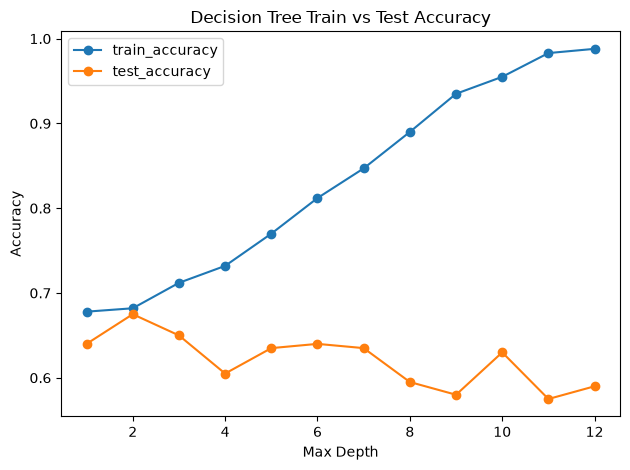

True

In [21]:
# Depth 그래프
depth_figure_path = (
    output_dir
    / "customer_churn_decision_tree_depth_comparison.png"
)

depth_df.plot(
    x="max_depth",
    y=[
        "train_accuracy",
        "test_accuracy",
    ],
    marker="o"
)

plt.title(
    "Decision Tree Train vs Test Accuracy"
)

plt.xlabel(
    "Max Depth"
)

plt.ylabel(
    "Accuracy"
)

plt.tight_layout()

plt.savefig(
    depth_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
depth_figure_path.exists()

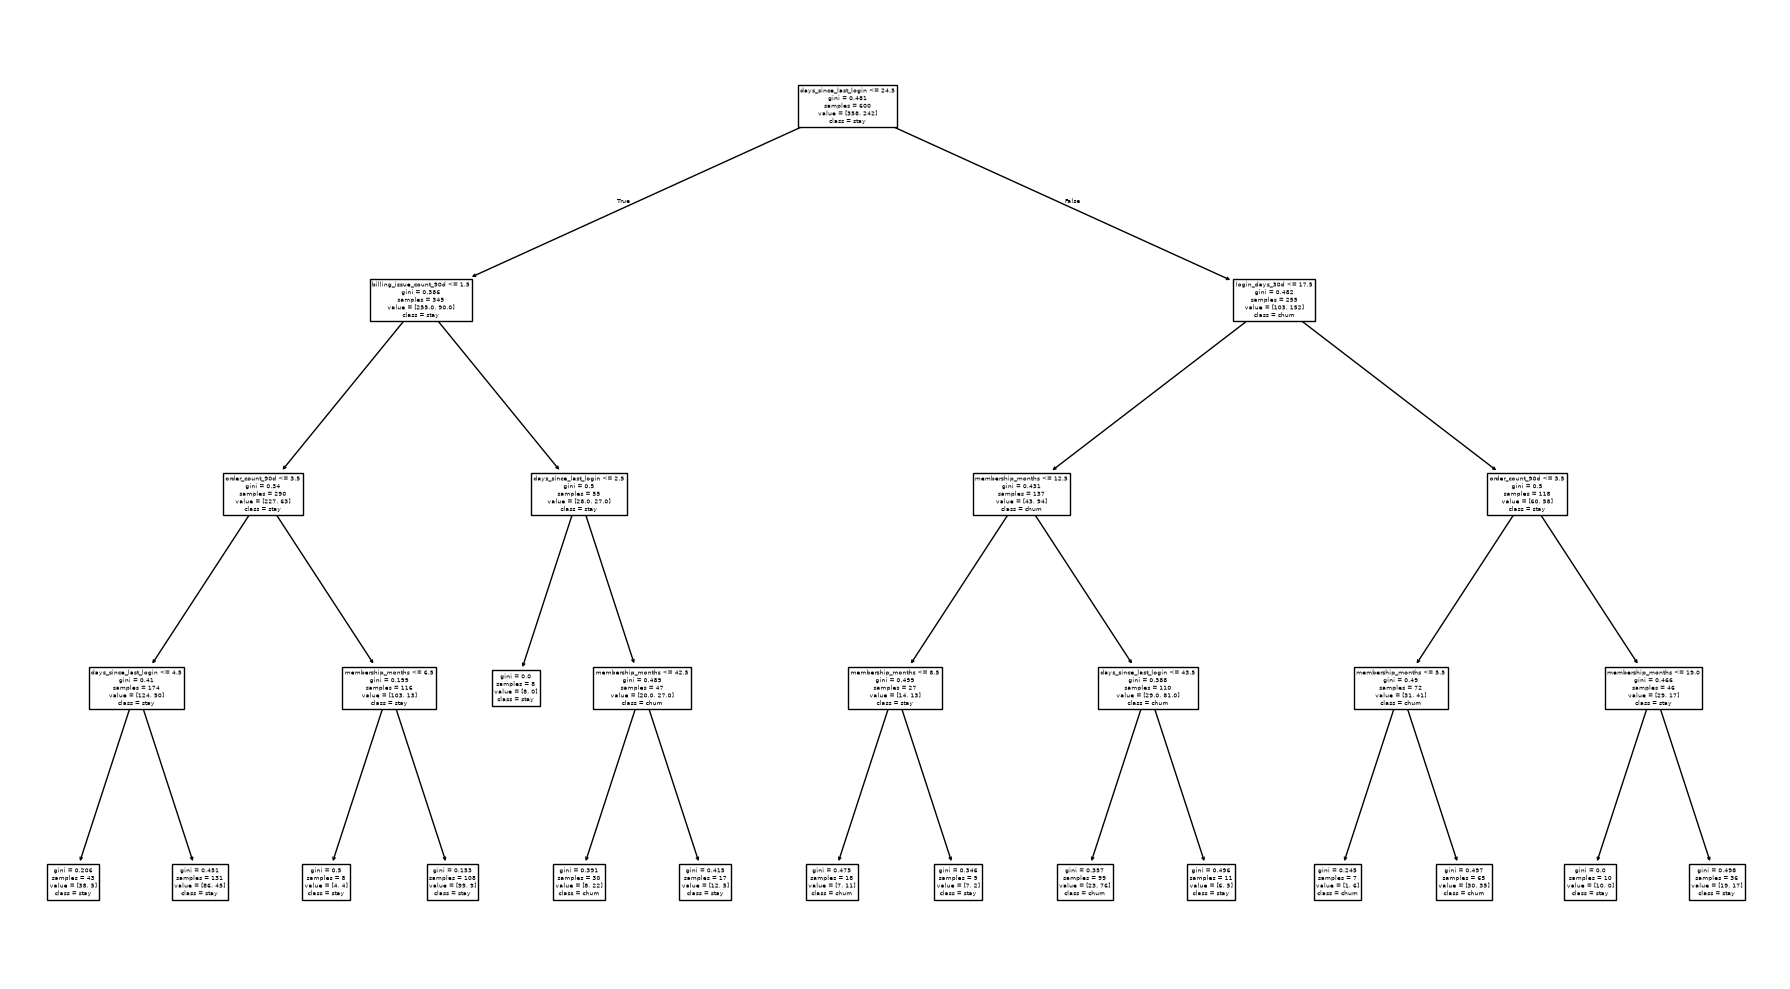

True

In [22]:
# Tree 구조 시각화
tree_figure_path = (
    output_dir
    / "customer_churn_decision_tree_structure.png"
)

plt.figure(
    figsize=(
        18,
        10
    )
)

plot_tree(
    limited_model,
    feature_names=features,
    class_names=[
        "stay",
        "churn",
    ]
)

plt.tight_layout()

plt.savefig(
    tree_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
tree_figure_path.exists()

In [23]:
# Metrics 저장
metrics_df = pd.DataFrame(
    {
        "model": [
            "unlimited_tree",
            "max_depth_4_tree",
        ],
        "train_accuracy": [
            unlimited_train_accuracy,
            limited_train_accuracy,
        ],
        "test_accuracy": [
            unlimited_test_accuracy,
            limited_test_accuracy,
        ],
    }
)

print(
    metrics_df
)

              model  train_accuracy  test_accuracy
0    unlimited_tree        1.000000          0.585
1  max_depth_4_tree        0.731667          0.605


In [24]:
# Prediction 저장
prediction_df = pd.DataFrame(
    {
        "customer_id": df.loc[
            X_test.index,
            "customer_id"
        ],
        "actual_churn": y_test,
    }
)

prediction_df[
    "predicted_churn"
] = limited_test_prediction

print(
    prediction_df.head(
        10
    )
)

     customer_id  actual_churn  predicted_churn
677          678             0                1
403          404             0                1
206          207             1                1
795          796             0                0
788          789             0                0
461          462             0                0
488          489             0                1
595          596             0                0
681          682             0                1
22            23             1                1


In [25]:
# CSV 저장
metrics_path = (
    output_dir
    / "customer_churn_decision_tree_metrics.csv"
)

confusion_path = (
    output_dir
    / "customer_churn_decision_tree_confusion_matrix.csv"
)

depth_path = (
    output_dir
    / "customer_churn_decision_tree_depth_comparison.csv"
)

prediction_path = (
    output_dir
    / "customer_churn_decision_tree_predictions.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

confusion_df.to_csv(
    confusion_path
)

depth_df.to_csv(
    depth_path,
    index=False
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

print(
    metrics_path
)

print(
    confusion_path
)

print(
    depth_path
)

print(
    prediction_path
)

d:\Study\Projects\00_foundation_review\outputs\customer_churn_decision_tree_metrics.csv
d:\Study\Projects\00_foundation_review\outputs\customer_churn_decision_tree_confusion_matrix.csv
d:\Study\Projects\00_foundation_review\outputs\customer_churn_decision_tree_depth_comparison.csv
d:\Study\Projects\00_foundation_review\outputs\customer_churn_decision_tree_predictions.csv


## 최종 해석

### 제한 없는 Decision Tree

- Train Accuracy: 1.000
- Test Accuracy: 0.585

깊이를 제한하지 않은 Decision Tree는 Train 데이터에서 매우 높은 정확도를 보였지만 Test 데이터에서는 성능이 크게 낮아졌다.

이는 Train 데이터를 지나치게 세밀하게 학습한 과적합 가능성을 보여준다.

### max_depth=4 Decision Tree

- Train Accuracy: 0.732
- Test Accuracy: 0.605
- Precision: 0.506
- Recall: 0.500
- F1 Score: 0.503

Tree의 깊이를 제한하면 Train 데이터를 완벽하게 맞히는 능력은 감소하지만 모델 복잡도를 제한할 수 있다.

### Depth 실험

Tree 깊이가 증가할수록 Train Accuracy는 전반적으로 증가했다.

그러나 Test Accuracy는 깊이에 따라 지속적으로 증가하지 않았으며, 모델을 더 복잡하게 만드는 것이 새로운 데이터에서 더 좋은 성능을 보장하지 않는다는 점을 확인했다.

이번 depth 실험은 과적합을 이해하기 위한 학습용 실험이다. 실제 모델 선택에서는 Test 데이터를 반복해서 확인하며 하이퍼파라미터를 결정해서는 안 된다.

### 업무 해석

분류 모델은 Accuracy만으로 평가하지 않는다.

이탈 고객을 놓치는 FN과 실제 유지 고객을 이탈 대상으로 선정하는 FP의 업무 비용을 함께 고려해야 한다.

### 한계

이번 데이터는 머신러닝 학습을 위해 생성한 가상 데이터다.

Decision Tree가 특정 Feature를 분할 조건으로 사용했다고 해서 해당 Feature가 고객 이탈의 인과적 원인이라는 뜻은 아니다.

실제 모델 선택에서는 별도의 Validation 데이터나 Cross Validation을 이용한 검증 과정이 추가로 필요하다.